# Losing Sleep at the Market — reproduction of Kamstra, Kramer & Levi (2000)
EDHEC MSc DA&AI · Statistical Models · Group 8

Code as extracted from the group report (`Statistical_Models___Report.docx`), split into cells; logic unchanged.

In [1]:
# Environment versions (required by the brief)
import sys, importlib
print('Python', sys.version.split()[0])
for m in ['yfinance','pandas','numpy','scipy','statsmodels','matplotlib','seaborn']:
    try: print(f'{m:12s}', importlib.import_module(m).__version__)
    except ImportError: print(f'{m:12s} not installed')

Python 3.14.3
yfinance     1.7.0
pandas       3.0.6
numpy        2.5.3
scipy        1.18.1
statsmodels  0.15.0
matplotlib   3.11.2
seaborn      0.13.2


## Import python libraries

In [2]:
# ===========================================
# IMPORT PYTHON LIBRARIES

import yfinance as yf
import pandas as pd
from zoneinfo import ZoneInfo
from datetime import date, timedelta
import os
import matplotlib.pyplot as plt

## Import data from yfinance

In [3]:
# ===========================================
# IMPORT DATA FROM YFINANCE

ticker = "^GSPC"
prices = yf.download(
   ticker,
   start="1966-12-31",
   end="2026-01-01",       # end is exclusive, ending with 2025-12-31
   auto_adjust=False,
   progress=False
)

Fig Config

In [4]:
plt.rcParams.update({"font.size": 13, "axes.titlesize": 15, "axes.titleweight": "bold",
                     "axes.spines.top": False, "axes.spines.right": False,
                     "figure.dpi": 110, "savefig.dpi": 300, "savefig.bbox": "tight"})
GREY, ACCENT, SPRING_C, AUTUMN_C = "#9a9a9a", "#c0392b", "#2e86c1", "#d35400"

def mean_ci(x):
    """Mean and 95% CI half-width (normal approximation)."""
    return x.mean(), 1.96 * x.std(ddof=1) / np.sqrt(len(x))

## Creation of the 'return_table' table, columns = (date, price, return)

In [5]:
# ===========================================
# CREATION OF THE 'RETURN_TABLE' TABLE, COLUMNS = (DATE, PRICE, RETURN)

# Creation of the 'Price' column using the 'Adj Close' column from yfinance and clean the data
if isinstance(prices.columns, pd.MultiIndex):
   prices = prices["Adj Close"].iloc[:, 0]
else:
   prices = prices["Adj Close"]

prices = prices.dropna()
prices.name = "Price"

# Create the 'Return' column using the 'Price' column
returns = 100 * (prices / prices.shift(1) - 1)

# Create of the 'Data' table
return_table = pd.DataFrame({
   "Price": prices,
   "Return": returns
})

## Creation of 'offset_series' table, returning calendar dates to utc offset

In [6]:
# ===========================================
# CREATION OF 'OFFSET_SERIES' TABLE, RETURNING CALENDAR DATES TO UTC OFFSET

# Select the time zone
ny = ZoneInfo("America/New_York")

# Creation the 'dates' list to store calendar dates
start = date(1966, 12, 31)
end = date(2025, 12, 31)
dates = pd.date_range(start=start, end=end, freq="D")

# Create the 'offsets' list to store UTC offsets for the selected time zone
offsets = []
for d in dates:
   dt = d.to_pydatetime().replace(tzinfo=ny, hour=12)
   offsets.append(dt.utcoffset())

# Create the 'offset_series' table by mapping the dates to their corresponding UTC offsets
offset_series = pd.Series(offsets, index=dates)

## Creation of 'transition_table' table, used to store utc offset changes

In [7]:
# ===========================================
# CREATION OF 'TRANSITION_TABLE' TABLE, USED TO STORE UTC OFFSET CHANGES
transition_table = []

# Create the 'transition_dates' list to store dates from 'offset_series' on which the UTC offset changes
transition_dates = []
for i in range(1, len(offset_series)):
   if offset_series.iloc[i] != offset_series.iloc[i - 1]:
       transition_dates.append(offset_series.index[i].date())

for transition_date in transition_dates:
   # Store the UTC offset before the change
   old_offset = offset_series.loc[
       pd.Timestamp(transition_date) - pd.Timedelta(days=1)
   ]
   # Store the UTC offset after the change
   new_offset = offset_series.loc[
       pd.Timestamp(transition_date)
   ]

   # Determine whether the transition occurs in Autumn or Spring
   if new_offset > old_offset:
       transition = "Spring"
   else:
       transition = "Autumn"

   # Add the transition information to the 'transition_table'
   transition_table.append({
       "transition_date": transition_date,
       "transition": transition,
       "old_UTC_offset": str(old_offset),
       "new_UTC_offset": str(new_offset)
   })

transition_table = pd.DataFrame(transition_table)

## Creation of the 'affected_days' list, used to store stock-market days

In [8]:
# ===========================================
# CREATION OF THE 'AFFECTED_DAYS' LIST, USED TO STORE STOCK-MARKET DAYS
# AFFECTED BY DST CHANGES, AS STOCK MARKET CALENDAR EXCLUDES WEEK-ENDS

# Create a list of stock-market trading days from the 'prices' table
trading_days = prices.index.normalize()

affected_days = []
for transition_date in transition_table["transition_date"]:

   # Select the first available trading day and store it in the 'affected_days' list
   candidates = trading_days[
       trading_days > pd.Timestamp(transition_date)
   ]
   if len(candidates) == 0:
       affected_day = pd.NaT
   else:
       affected_day = candidates[0].date()
   affected_days.append(affected_day)

transition_table["affected_trading_day"] = affected_days

# Create a dictionnary linking each affected trading day to its transition type
transition_lookup = dict(
   zip(
       transition_table["affected_trading_day"],
       transition_table["transition"]
   )
)

## Completion of 'return_table' table, new columns = (dst_transition, dst_spring, dst_autumn)

In [9]:
# ===========================================
# COMPLETION OF 'RETURN_TABLE' TABLE, NEW COLUMNS = (DST_TRANSITION, DST_SPRING, DST_AUTUMN)

# Map each date in the 'data' table to its corresponding transition using 'None' when no DST transition occurs
return_table["DST_transition"] = return_table.index.map(
   lambda x: transition_lookup.get(x.date(), "None")
)

# Optional feature : create dummy-columns to store indicator values depending of the transition
return_table["DST_spring"] = (return_table["DST_transition"] == "Spring").astype(int)
return_table["DST_autumn"] = (return_table["DST_transition"] == "Autumn").astype(int)

# Optional feature : create a filtered table containing only days affected by DST transitions
affected = return_table[(return_table["DST_spring"] == 1) |(return_table["DST_autumn"] == 1)]

## Display and export (commented out)

In [10]:
# ===========================================
# DISPLAY THE 'RETURN_TABLE' AND 'TRANSITION_TABLE'

print("\nDST TRANSITION TABLE")
print(transition_table.to_string(index=False))

print("\nAFFECTED TRADING DAYS")
print(affected.to_string())

# ===========================================
# EXPORT THE 'RETURN_TABLE' AND 'TRANSITION_TABLE' TABLES

#data.to_csv("sp500_daily_returns.csv", index=False)
transition_table.to_csv("us_dst_transition_dates.csv", index=False)


DST TRANSITION TABLE
transition_date transition    old_UTC_offset    new_UTC_offset affected_trading_day
     1967-04-30     Spring -1 days +19:00:00 -1 days +20:00:00           1967-05-01
     1967-10-29     Autumn -1 days +20:00:00 -1 days +19:00:00           1967-10-30
     1968-04-28     Spring -1 days +19:00:00 -1 days +20:00:00           1968-04-29
     1968-10-27     Autumn -1 days +20:00:00 -1 days +19:00:00           1968-10-28
     1969-04-27     Spring -1 days +19:00:00 -1 days +20:00:00           1969-04-28
     1969-10-26     Autumn -1 days +20:00:00 -1 days +19:00:00           1969-10-27
     1970-04-26     Spring -1 days +19:00:00 -1 days +20:00:00           1970-04-27
     1970-10-25     Autumn -1 days +20:00:00 -1 days +19:00:00           1970-10-26
     1971-04-25     Spring -1 days +19:00:00 -1 days +20:00:00           1971-04-26
     1971-10-31     Autumn -1 days +20:00:00 -1 days +19:00:00           1971-11-01
     1972-04-30     Spring -1 days +19:00:00 -1 days +

## Analysis libraries

In [11]:
# PYTHON LIBRARIES

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

## Sample construction and descriptive statistics (Tables 1–3)

In [12]:
# TABLE 1: Sample Construction
analysis_data = return_table.dropna(subset=["Return"]).copy()
analysis_data["DST"] = ((analysis_data["DST_spring"] == 1) | (analysis_data["DST_autumn"] == 1)).astype(int)

n_observations = len(analysis_data)
n_transitions = len(transition_table)
n_no_dst = (analysis_data["DST"] == 0).sum()
n_dst = (analysis_data["DST"] == 1).sum()
n_spring = analysis_data["DST_spring"].sum()
n_autumn = analysis_data["DST_autumn"].sum()

assert all(pd.Timestamp(d).dayofweek == 6 for d in transition_table["transition_date"]), "a transition is not on a Sunday"
assert n_dst == n_transitions, f"{n_transitions} transitions but {n_dst} DST observations in the sample"

sample_table = pd.DataFrame({
   "Value": [f"{analysis_data.index.min().date()} to {analysis_data.index.max().date()}", n_observations, n_transitions, n_dst, n_spring, n_autumn, n_no_dst]
}, index=["Sample period (returns)", "Trading-day observations", "DST transitions", "DST trading days", " of which Spring", " of which Autumn", "Other trading days"
])

print("\nTABLE 1 - SAMPLE CONSTRUCTION")
print(sample_table)

# TABLE 2 : Statistics for dates with vs. without transitions
descriptive_stats = (
   analysis_data.groupby("DST")["Return"]
   .agg(N="count", Mean="mean", Std="std", Median="median", Min="min", Max="max"))
print("\nDESCRIPTIVE STATISTICS : Transitions (No/Yes)")
print(descriptive_stats)

# TABLE 3 : Statistics for Spring vs. Autumn transitions
season_stats = (
   analysis_data[analysis_data["DST"] == 1]
   .groupby("DST_transition")["Return"]
   .agg(N="count", Mean="mean", Std="std", Median="median", Min="min", Max="max"))
print("\nDESCRIPTIVE STATISTICS : Spring vs. Autumn transitions")
print(season_stats)


TABLE 1 - SAMPLE CONSTRUCTION
                                             Value
Sample period (returns)   1967-01-04 to 2025-12-31
Trading-day observations                     14847
DST transitions                                118
DST trading days                               118
 of which Spring                                59
 of which Autumn                                59
Other trading days                           14729

DESCRIPTIVE STATISTICS : Transitions (No/Yes)
         N      Mean       Std    Median        Min        Max
DST                                                           
0    14729  0.037557  1.059221  0.048117 -20.466931  11.580037
1      118 -0.206465  1.442354  0.044031  -8.278947   2.222354

DESCRIPTIVE STATISTICS : Spring vs. Autumn transitions
                 N      Mean       Std    Median       Min       Max
DST_transition                                                      
Autumn          59 -0.170826  1.586946  0.088779 -8.278947  2.222354

## Figures: distribution + q-q plot

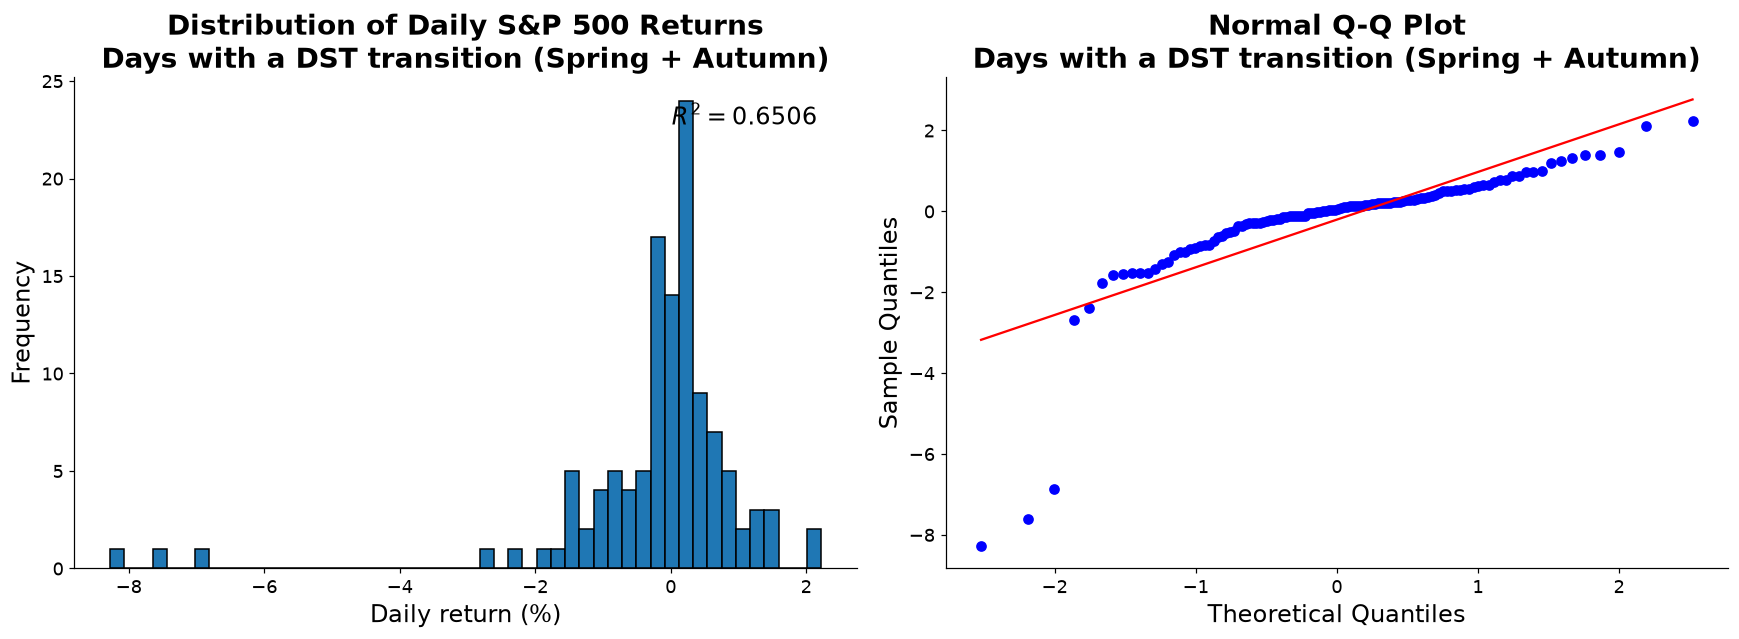

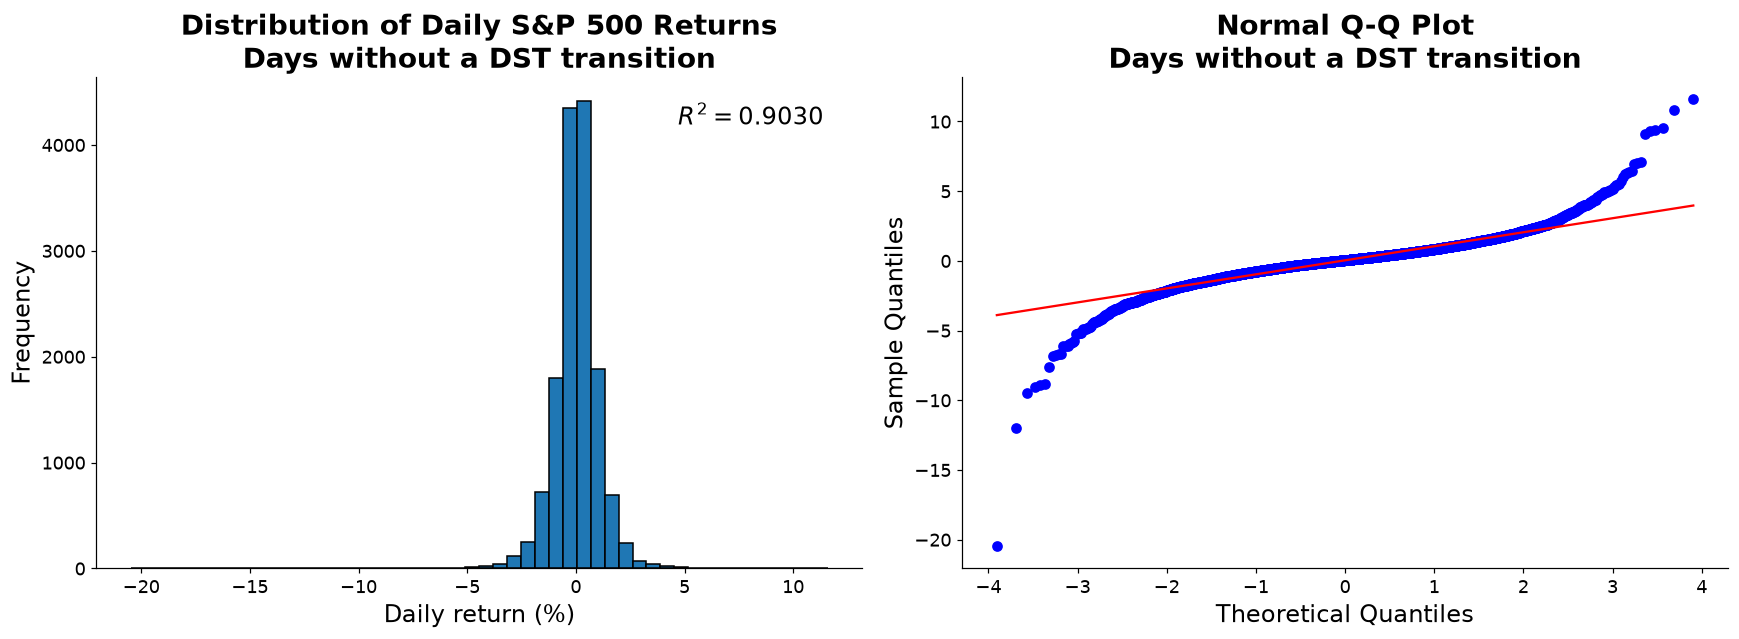

In [13]:
# ===========================================
# FIGURES: DISTRIBUTION + Q-Q PLOT
# ===========================================

# Function to create a distribution + Q-Q plot
def plot_distribution_qq(data, title):
   fig, axes = plt.subplots(1, 2, figsize=(16, 6))
  
   # Distribution
   axes[0].hist(data, bins=50, edgecolor="black")
   axes[0].set_xlabel("Daily return (%)", fontsize=16)
   axes[0].set_ylabel("Frequency", fontsize=16)
   axes[0].set_title(f"Distribution of Daily S&P 500 Returns\n{title}", fontsize=18)
   axes[0].tick_params(axis="both", labelsize=12)

   # Q-Q plot + R² calculation
   (theoretical_quantiles, sample_quantiles), (slope, intercept, r) = \
       stats.probplot(data, dist="norm")

   r_squared = r**2

   stats.probplot(data, dist="norm", plot=axes[1])
   axes[1].set_title(f"Normal Q-Q Plot\n{title}", fontsize=18)
   axes[1].set_xlabel("Theoretical Quantiles", fontsize=16)
   axes[1].set_ylabel("Sample Quantiles", fontsize=16)
   axes[1].tick_params(axis="both", labelsize=12)

   # Add R² to the left graph
   axes[0].text(
       0.95, 0.95,
       f"$R^2 = {r_squared:.4f}$",
       transform=axes[0].transAxes,
       fontsize=16,
       verticalalignment="top",
       horizontalalignment="right"
   )

   plt.tight_layout()
   plt.show()

# 1. DAYS WITH A DST TRANSITION : Spring + Autumn
# ===========================================
returns_dst = analysis_data.loc[analysis_data["DST"] == 1,"Return"].dropna()
plot_distribution_qq(returns_dst,"Days with a DST transition (Spring + Autumn)")

# 2. DAYS WITHOUT A DST TRANSITION
# ===========================================
returns_no_dst = analysis_data.loc[analysis_data["DST"] == 0, "Return"].dropna()
plot_distribution_qq(returns_no_dst, "Days without a DST transition")

## Question 3: the daylight-saving effect

In [14]:
# ===========================================
# QUESTION 3: THE DAYLIGHT-SAVING EFFECT
# ===========================================

# -------------------------------------------
# 1. Regression: Spring + Autumn together
# -------------------------------------------

# Keep all observations, with DST = 1 for
# Spring or Autumn and DST = 0 otherwise
mod = smf.ols(formula="Return ~ DST", data=analysis_data)
res = mod.fit(cov_type = "HC1") # robust to unequal variances + onesided test report

b_dst, t_dst = res.params["DST"], res.tvalues["DST"]
p_onesided = stats.norm.cdf(t_dst) # H1: beta < 0

# Display regression results
print("\nREGRESSION: DST EFFECT")
print(res.summary())
print(f"DST coef = {b_dst:.4f} pp, robust t = {t_dst:.3f}, one-sided p = {p_onesided:.4f}")
print(f"Non-robust SE: {mod.fit().bse['DST']:.4f} vs robust SE: {res.bse['DST']:.4f}")


REGRESSION: DST EFFECT
                            OLS Regression Results                            
Dep. Variable:                 Return   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     3.391
Date:                Mon, 05 Oct 2026   Prob (F-statistic):             0.0656
Time:                        11:40:17   Log-Likelihood:                -21970.
No. Observations:               14847   AIC:                         4.394e+04
Df Residuals:                   14845   BIC:                         4.396e+04
Df Model:                           1                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0376      0

## QUESTION 4: The calendar diagnostic

In [15]:
def dst_row(res, name, term="DST"):
    """One row of the comparison table: coefficient, classic and robust SEs, one-sided p (H1: beta < 0)."""
    row = {"Specification": name, "N": int(res.nobs), "beta_DST (pp)": res.params[term]}
    if isinstance(res.model, sm.OLS):
        classic = res.model.fit()          # same model and data, conventional (equal-variance) SEs
        row.update({"SE classic": classic.bse[term],
                    "t classic": classic.tvalues[term],
                    "p classic": stats.norm.cdf(classic.tvalues[term])})
    else:                                  # median regression: no classic OLS counterpart
        row.update({"SE classic": np.nan, "t classic": np.nan, "p classic": np.nan})
    row.update({"SE": res.bse[term], "t": res.tvalues[term],
                "one-sided p": stats.norm.cdf(res.tvalues[term])})
    return row

comparison = [dst_row(res, "(1) Return ~ DST")]

In [16]:
day_names = {0: "Mon", 1: "Tue", 2: "Wed", 3: "Thu", 4: "Fri"}
analysis_data["weekday"] = analysis_data.index.dayofweek.map(day_names)
assert analysis_data["weekday"].notna().all(), "a trading day falls on a weekend"

print("DST days by weekday:")
print(pd.crosstab(analysis_data["weekday"], analysis_data["DST"]))

print("\nMean return by weekday (non-DST days):")
print(analysis_data[analysis_data["DST"] == 0].groupby("weekday")["Return"].agg(["count", "mean", "std"]))

res2 = smf.ols("Return ~ DST + C(weekday, Treatment(reference='Mon'))",
               data=analysis_data).fit(cov_type="HC1")
print(res2.summary())

# Joint test that the weekday dummies matter at all (robust Wald test)
wd_terms = [n for n in res2.params.index if n.startswith("C(weekday")]
R = np.array([[1.0 if n == t else 0.0 for n in res2.params.index] for t in wd_terms])
print("\nJoint test that all weekday dummies = 0:")
print(res2.f_test(R))

# Spring and autumn separately, with weekday controls
res2s = smf.ols("Return ~ DST_spring + DST_autumn + C(weekday, Treatment(reference='Mon'))",
                data=analysis_data).fit(cov_type="HC1")
comparison += [dst_row(res2, "(2) + weekday dummies"),
               dst_row(res2s, "(2a) Spring only, + weekday", term="DST_spring"),
               dst_row(res2s, "(2b) Autumn only, + weekday", term="DST_autumn")]
print(pd.DataFrame(comparison).round(4).to_string(index=False))

DST days by weekday:
DST         0    1
weekday           
Fri      2972    0
Mon      2704  118
Thu      2985    0
Tue      3043    0
Wed      3025    0

Mean return by weekday (non-DST days):
         count      mean       std
weekday                           
Fri       2972  0.044386  0.989925
Mon       2704 -0.012512  1.195938
Thu       2985  0.024288  1.039769
Tue       3043  0.055119  1.046805
Wed       3025  0.071033  1.024722
                            OLS Regression Results                            
Dep. Variable:                 Return   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     2.565
Date:                Mon, 05 Oct 2026   Prob (F-statistic):             0.0251
Time:                        11:40:17   Log-Likelihood:                -21965.
No. Observations:               14847   AIC:                         4.394e+04
Df Resid

## Figure 1: Mean returns, DST days vs ordinary days

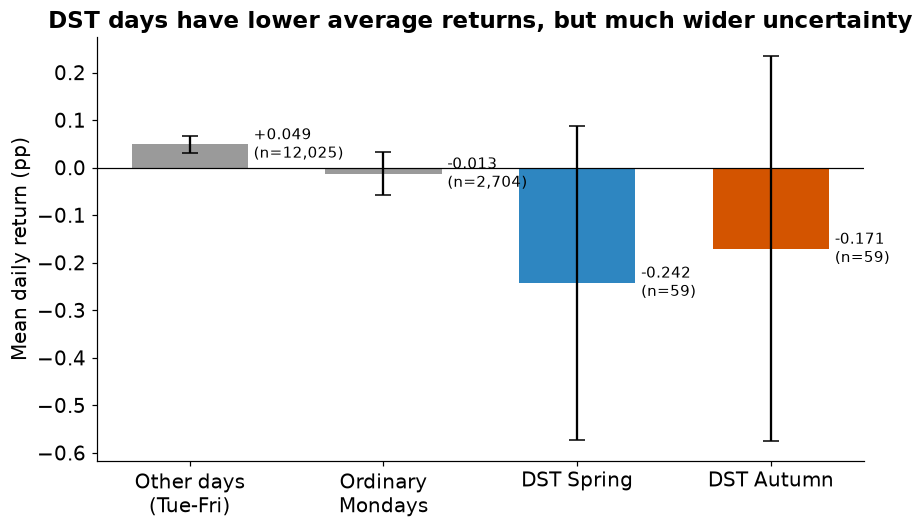

In [17]:
groups = {
    "Other days\n(Tue-Fri)":  analysis_data.loc[(analysis_data.DST == 0) & (analysis_data.weekday != "Mon"), "Return"],
    "Ordinary\nMondays":      analysis_data.loc[(analysis_data.DST == 0) & (analysis_data.weekday == "Mon"), "Return"],
    "DST Spring":             analysis_data.loc[analysis_data.DST_spring == 1, "Return"],
    "DST Autumn":             analysis_data.loc[analysis_data.DST_autumn == 1, "Return"],
}
stats_g = {k: mean_ci(v) for k, v in groups.items()}
fig, ax = plt.subplots(figsize=(9, 5))
colors = [GREY, GREY, SPRING_C, AUTUMN_C]
for i, (k, (m, ci)) in enumerate(stats_g.items()):
    ax.bar(i, m, color=colors[i], width=0.6)
    ax.errorbar(i, m, yerr=ci, color="black", capsize=5)
    ax.text(i + 0.33, m, f"{m:+.3f}\n(n={len(groups[k]):,})", ha="left", va="center", fontsize=10)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(range(len(groups)), groups.keys())
ax.set_ylabel("Mean daily return (pp)")
ax.set_title("DST days have lower average returns, but much wider uncertainty")
plt.savefig("fig1_group_means.png")
plt.show()

## QUESTION 5: Where the extreme returns are

In [18]:
lo, hi = analysis_data.Return.quantile([0.01, 0.99])
analysis_data["extreme"] = (analysis_data["Return"]<lo) | (analysis_data["Return"]>hi)

print(f"1% / 99% cut-offs: {lo:.2f}% / {hi:.2f}%")
print(pd.crosstab(analysis_data["DST"], analysis_data["extreme"], margins=True))
print(f"Share of extreme days: DST {analysis_data.loc[analysis_data.DST == 1, 'extreme'].mean():.1%}"
      f" vs other {analysis_data.loc[analysis_data.DST == 0, 'extreme'].mean():.1%} (2% by construction overall)")

print("\nFive most negative DST-day returns:")
print(analysis_data.loc[analysis_data.DST ==1, ["Return", "DST_transition", "weekday"]].nsmallest(5, "Return"))

# how much does beta move when each DST day is dropped? 
loo = []
for d in analysis_data.index[analysis_data.DST == 1]:
    r = smf.ols(formula = "Return ~ DST + C(weekday, Treatment(reference='Mon'))", data = analysis_data.drop(index=d)).fit(cov_type='HC1')
    loo.append({"dropped day": d.date(), "Return that day": analysis_data.loc[d, "Return"],
    "beta without it": r.params["DST"], "one-sided p without it": stats.norm.cdf(r.tvalues["DST"])})
loo = pd.DataFrame(loo).sort_values("beta without it", ascending = False)

print("\nMost influential DST days (dropping them raises beta the most):")
print(loo.head(5).round(4).to_string(index=False))

1% / 99% cut-offs: -2.88% / 2.75%
extreme  False  True    All
DST                        
0        14434   295  14729
1          115     3    118
All      14549   298  14847
Share of extreme days: DST 2.5% vs other 2.0% (2% by construction overall)

Five most negative DST-day returns:
              Return DST_transition weekday
Date                                       
1987-10-26 -8.278947         Autumn     Mon
2020-03-09 -7.596970         Spring     Mon
1997-10-27 -6.865684         Autumn     Mon
2025-03-10 -2.697309         Spring     Mon
2001-10-29 -2.381830         Autumn     Mon

Most influential DST days (dropping them raises beta the most):
dropped day  Return that day  beta without it  one-sided p without it
 1987-10-26          -8.2789          -0.1250                  0.1412
 2020-03-09          -7.5970          -0.1308                  0.1370
 1997-10-27          -6.8657          -0.1370                  0.1320
 2025-03-10          -2.6973          -0.1727                

## Figure 2: DST-day returns over time

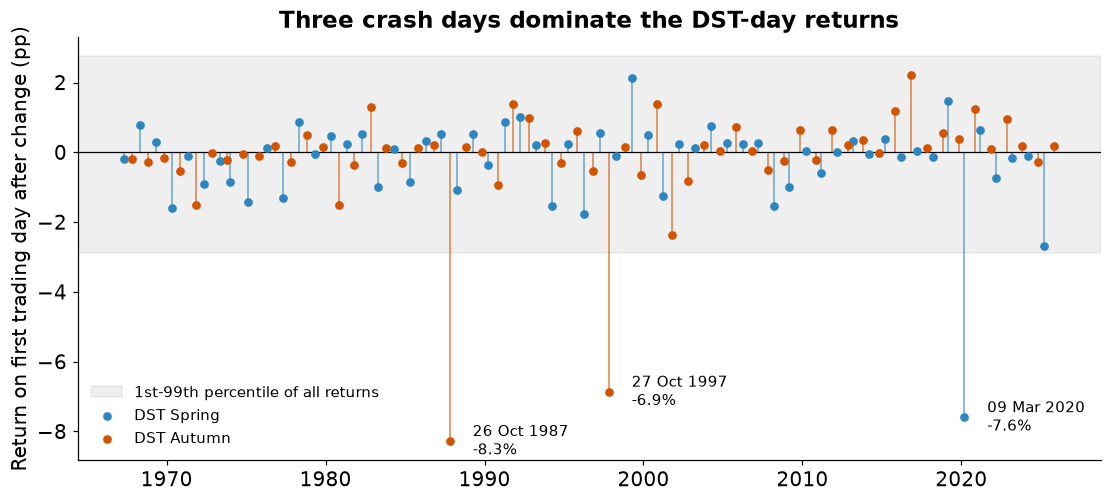

In [19]:
dst = analysis_data[analysis_data.DST == 1]
fig, ax = plt.subplots(figsize=(12, 5))
ax.axhspan(lo, hi, color=GREY, alpha=0.15, label="1st-99th percentile of all returns")
for kind, c in [("Spring", SPRING_C), ("Autumn", AUTUMN_C)]:
    d = dst[dst.DST_transition == kind]
    ax.vlines(d.index, 0, d.Return, color=c, alpha=0.6, linewidth=1.2)
    ax.scatter(d.index, d.Return, color=c, s=22, label=f"DST {kind}", zorder=3)
for day, r in dst.Return.nsmallest(3).items():
    ax.annotate(f"{day:%d %b %Y}\n{r:.1f}%", xy=(day, r), xytext=(15, 0),
                textcoords="offset points", fontsize=10, va="center")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Return on first trading day after change (pp)")
ax.set_title("Three crash days dominate the DST-day returns")
ax.legend(loc="lower left", frameon=False, fontsize=10)
plt.savefig("fig2_dst_returns_timeline.png") 
plt.show()

## Figure 3: DST effect as extreme days are removed

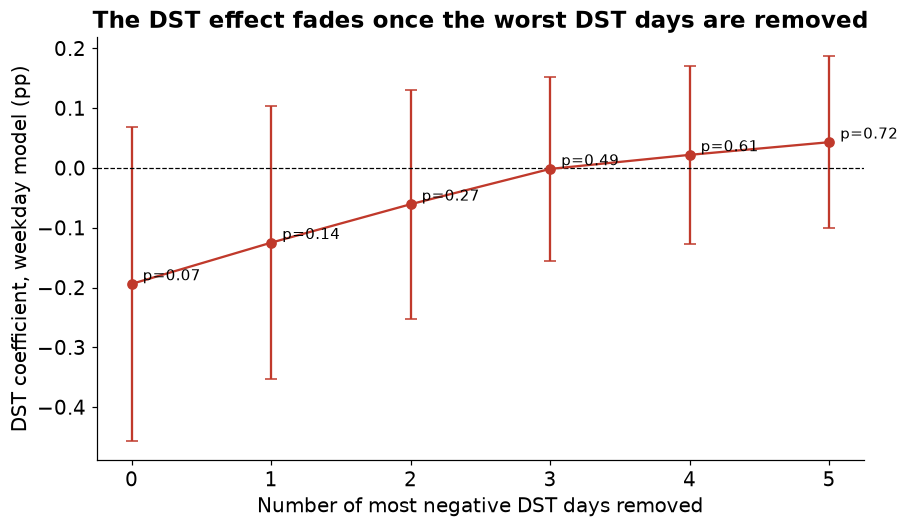

In [20]:
order = dst.Return.sort_values().index          # most negative first
path = []
for k in range(0, 6):
    r = smf.ols("Return ~ DST + C(weekday, Treatment(reference='Mon'))",
                data=analysis_data.drop(index=order[:k])).fit(cov_type="HC1")
    path.append((k, r.params["DST"], r.bse["DST"], stats.norm.cdf(r.tvalues["DST"])))
path = pd.DataFrame(path, columns=["k", "beta", "se", "p"])
fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(path.k, path.beta, yerr=1.96 * path.se, fmt="o-", color=ACCENT, capsize=4)
for _, row in path.iterrows():
    ax.text(row.k + 0.08, row.beta, f"p={row.p:.2f}", fontsize=10, va="bottom")
ax.axhline(0, color="black", linestyle="--", linewidth=0.8)
ax.set_xticks(path.k)
ax.set_xlabel("Number of most negative DST days removed")
ax.set_ylabel("DST coefficient, weekday model (pp)")
ax.set_title("The DST effect fades once the worst DST days are removed")
plt.savefig("fig3_beta_drop_extremes.png")  
plt.show()

## QUESTION 5: Robustness: re-estimations

In [21]:
# (a) Winsorize all returns at the 1st/99th percentiles (same rule for both groups)
analysis_data["Return_w"] = analysis_data["Return"].clip(lower=lo, upper=hi)
res_w = smf.ols("Return_w ~ DST + C(weekday, Treatment(reference='Mon'))",
                data=analysis_data).fit(cov_type="HC1")

# (b) Drop the two most influential DST days
drop_days = pd.to_datetime(loo["dropped day"].head(2))
res_drop = smf.ols("Return ~ DST + C(weekday, Treatment(reference='Mon'))",
                   data=analysis_data.drop(index=drop_days)).fit(cov_type="HC1")

# (c) Extra check: median (quantile) regression, insensitive to extreme values
res_med = smf.quantreg("Return ~ DST + C(weekday, Treatment(reference='Mon'))",
                       data=analysis_data).fit(q=0.5)

comparison += [dst_row(res_w, "(3) + weekday, winsorized 1/99%"),
               dst_row(res_drop, "(4) + weekday, without 2 most influential DST days"),
               dst_row(res_med, "(5) Median regression + weekday")]
comparison_table = pd.DataFrame(comparison)
print(comparison_table.round(4).to_string(index=False))

                                     Specification     N  beta_DST (pp)  SE classic  t classic  p classic     SE       t  one-sided p
                                  (1) Return ~ DST 14847        -0.2440      0.0982    -2.4842     0.0065 0.1325 -1.8415       0.0328
                             (2) + weekday dummies 14847        -0.1940      0.0999    -1.9409     0.0261 0.1342 -1.4450       0.0742
                       (2a) Spring only, + weekday 14847        -0.2296      0.1398    -1.6418     0.0503 0.1687 -1.3609       0.0868
                       (2b) Autumn only, + weekday 14847        -0.1583      0.1398    -1.1321     0.1288 0.2062 -0.7678       0.2213
                   (3) + weekday, winsorized 1/99% 14847        -0.0849      0.0882    -0.9626     0.1679 0.0864 -0.9824       0.1629
(4) + weekday, without 2 most influential DST days 14845        -0.0607      0.1004    -0.6042     0.2729 0.0978 -0.6201       0.2676
                   (5) Median regression + weekday 14847      

## Figure 4: DST coefficient across specifications

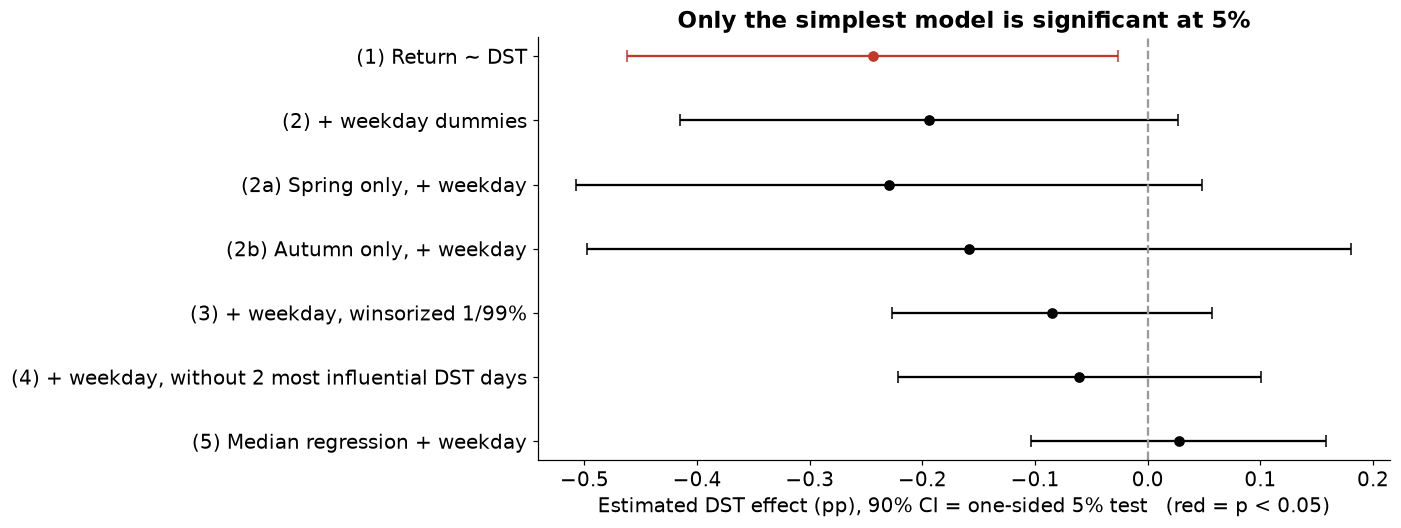

In [22]:
ct = comparison_table.iloc[::-1].reset_index(drop=True)
fig, ax = plt.subplots(figsize=(10, 5))
for i, row in ct.iterrows():
    c = ACCENT if row["one-sided p"] < 0.05 else "black"
    ax.errorbar(row["beta_DST (pp)"], i, xerr=1.645 * row["SE"], fmt="o", color=c, capsize=4)
ax.axvline(0, color=GREY, linestyle="--")
ax.set_yticks(range(len(ct)), ct["Specification"])
ax.set_xlabel("Estimated DST effect (pp), 90% CI = one-sided 5% test   (red = p < 0.05)")
ax.set_title("Only the simplest model is significant at 5%")
plt.savefig("fig4_coefficients.png")
plt.show()

## QUESTION 6: Comparison with Source paper

In [23]:
prev_dow = pd.Series(analysis_data.index.dayofweek, index=analysis_data.index).shift(1)
analysis_data["after_weekend"] = (analysis_data.index.dayofweek < prev_dow).astype(int)
assert analysis_data.loc[analysis_data["DST"] == 1, "after_weekend"].all(), "a DST day does not follow a weekend"

def paper_style(sub, label):
    wk = sub[sub["after_weekend"] == 1]
    r = smf.ols("Return ~ DST", data=wk).fit(cov_type="HC1")   # beta = DST weekend mean - regular weekend mean
    c = smf.ols("Return ~ DST", data = wk).fit() # same test, conventional SEs (as in the paper)
    return {"Sample": label,
            "Regular weekend": wk.loc[wk.DST == 0, "Return"].mean(),
            "Spring": wk.loc[wk.DST_spring == 1, "Return"].mean(),
            "Autumn": wk.loc[wk.DST_autumn == 1, "Return"].mean(),
            "N spring / autumn": f"{wk.DST_spring.sum()} / {wk.DST_autumn.sum()}",
            "t classic": c.tvalues["DST"], "p classic": stats.norm.cdf(c.tvalues["DST"]),
            "t robust": r.tvalues["DST"], "p robust": stats.norm.cdf(r.tvalues["DST"]),
            "one-sided p": stats.norm.cdf(r.tvalues["DST"])}

paper = {"Sample": "KKL (2000), S&P 500 1967-1997",
         "Regular weekend": -0.04079, "Spring": -0.14334, "Autumn": -0.54827,   # paper's decimals x 100
         "N spring / autumn": "30 / 30", "t classic": -2.5820, "p classic": 0.0049, "t robust": np.nan, "p robust": np.nan}

reproduction = pd.DataFrame([paper,
                             paper_style(analysis_data.loc[:"1997-12-31"], "Ours, 1967-1997"),
                             paper_style(analysis_data, "Ours, 1967-2025")])
print("Mean returns in percentage points")
print(reproduction.round(4).to_string(index=False))

Mean returns in percentage points
                       Sample  Regular weekend  Spring  Autumn N spring / autumn  t classic  p classic  t robust  p robust  one-sided p
KKL (2000), S&P 500 1967-1997          -0.0408 -0.1433 -0.5483           30 / 30    -2.5820     0.0049       NaN       NaN          NaN
              Ours, 1967-1997          -0.0393 -0.1806 -0.5309           31 / 31    -2.2442     0.0124   -1.6335    0.0512       0.0512
              Ours, 1967-2025          -0.0124 -0.2421 -0.1708           59 / 59    -1.7203     0.0427   -1.4479    0.0738       0.0738


## Figure 5: Kamstra et al. (2000) vs our reproduction

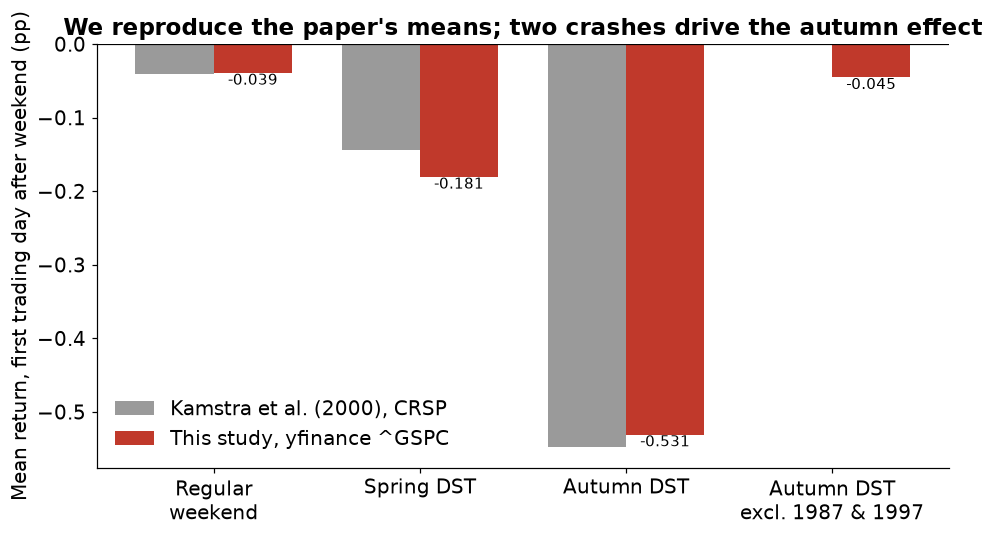

Autumn DST 1967-1997 excl. 1987 & 1997 crashes: -0.0452 pp (n=29)


In [24]:
wk = analysis_data.loc[:"1997-12-31"].query("after_weekend == 1")
crash_days = pd.to_datetime(["1987-10-26", "1997-10-27"])
ours = [wk.loc[wk.DST == 0, "Return"].mean(),
        wk.loc[wk.DST_spring == 1, "Return"].mean(),
        wk.loc[wk.DST_autumn == 1, "Return"].mean()]
autumn_ex = wk.loc[(wk.DST_autumn == 1) & ~wk.index.isin(crash_days), "Return"].mean()
labels = ["Regular\nweekend", "Spring DST", "Autumn DST", "Autumn DST\nexcl. 1987 & 1997"]
paper_vals = [-0.04079, -0.14334, -0.54827, np.nan]
our_vals = ours + [autumn_ex]
x = np.arange(len(labels)); w = 0.38
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w/2, paper_vals, w, color=GREY, label="Kamstra et al. (2000), CRSP")
ax.bar(x + w/2, our_vals, w, color=ACCENT, label="This study, yfinance ^GSPC")
for xi, v in zip(x + w/2, our_vals):
    ax.text(xi, v, f"{v:+.3f}", ha="center", va="bottom" if v >= 0 else "top", fontsize=10)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x, labels)
ax.set_ylabel("Mean return, first trading day after weekend (pp)")
ax.set_title("We reproduce the paper's means; two crashes drive the autumn effect")
ax.legend(frameon=False)
plt.savefig("fig5_paper_vs_ours.png")
plt.show()
print(f"Autumn DST 1967-1997 excl. 1987 & 1997 crashes: {autumn_ex:.4f} pp "
      f"(n={((wk.DST_autumn == 1) & ~wk.index.isin(crash_days)).sum()})")